In [12]:
# =============================
# STEP 1: Setup
# =============================
!pip install seaborn xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')


In [13]:
# =============================
# STEP 2: Upload Dataset (Fixed)
# =============================
from google.colab import files
uploaded = files.upload()

import io

# Get the uploaded file name dynamically
filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(io.BytesIO(uploaded[filename]))
df.head()


Saving calories.csv to calories (5).csv


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


Correlation with Calories:
 Calories      1.000000
Duration      0.955421
Heart_Rate    0.897882
Body_Temp     0.824558
Age           0.154395
Weight        0.035481
Height        0.017537
User_ID      -0.001661
Name: Calories, dtype: float64


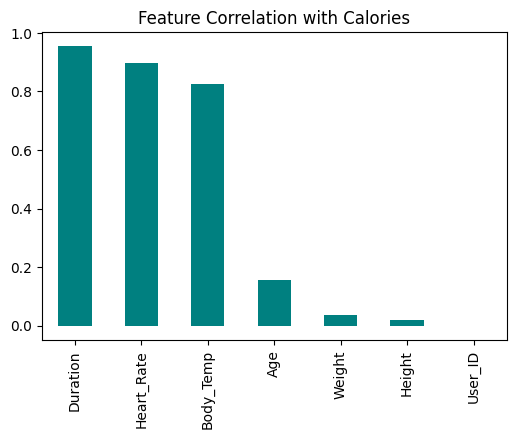

In [16]:
# =============================
# Q1: Which features affect calorie burn?
# =============================
# Show correlation with Calories
correlation = df.select_dtypes(include=['number']).corr()['Calories'].sort_values(ascending=False)
print("Correlation with Calories:\n", correlation)


plt.figure(figsize=(6,4))
correlation.drop('Calories').plot(kind='bar', color="teal")
plt.title("Feature Correlation with Calories")
plt.show()


In [17]:
# =============================
# Q2: How accurate is the model?
# =============================
# Preprocessing
df.replace({'male':0, 'female':1}, inplace=True)
df.drop(['User_ID'], axis=1, inplace=True)

X = df.drop(['Calories'], axis=1)
y = df['Calories']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=22)

model = LinearRegression()
model.fit(X_train, y_train)

train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)

print("Training Accuracy (R²):", train_score)
print("Validation Accuracy (R²):", val_score)


Training Accuracy (R²): 0.9672254115157872
Validation Accuracy (R²): 0.967058318318621


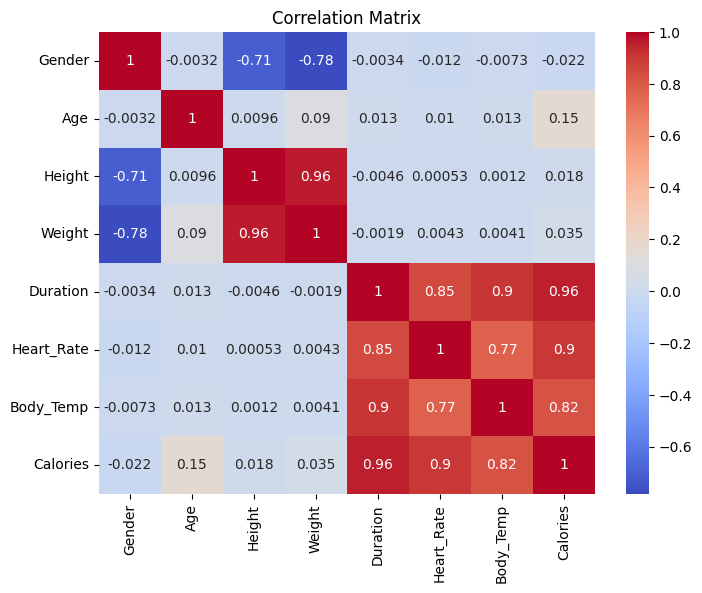

In [18]:
# =============================
# Q3: What is the correlation matrix?
# =============================
plt.figure(figsize=(8,6))
sb.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [19]:
# =============================
# Q4: How to handle missing values?
# =============================
print("Missing values before:", df.isnull().sum())

# Fill missing numeric with mean, categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

print("Missing values after:", df.isnull().sum())


Missing values before: Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64
Missing values after: Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


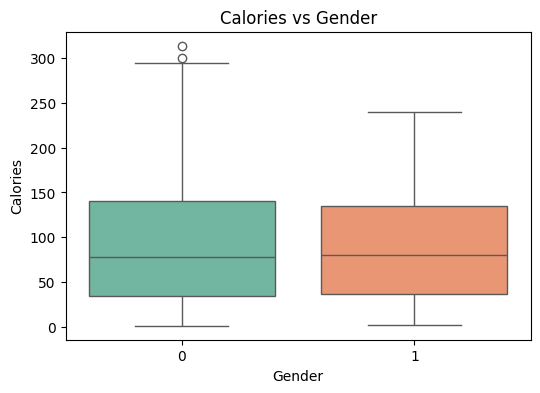

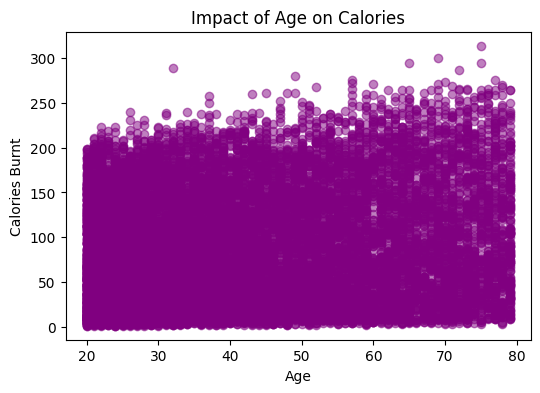

In [21]:
# =============================
# Q5: What is the impact of age/gender?
# =============================
plt.figure(figsize=(6,4))
sb.boxplot(x='Gender', y='Calories', data=df.replace({'male':0,'female':1}), palette="Set2")
plt.title("Calories vs Gender")
plt.show()


plt.figure(figsize=(6,4))
plt.scatter(df['Age'], df['Calories'], alpha=0.5, color="purple")
plt.xlabel("Age")
plt.ylabel("Calories Burnt")
plt.title("Impact of Age on Calories")
plt.show()


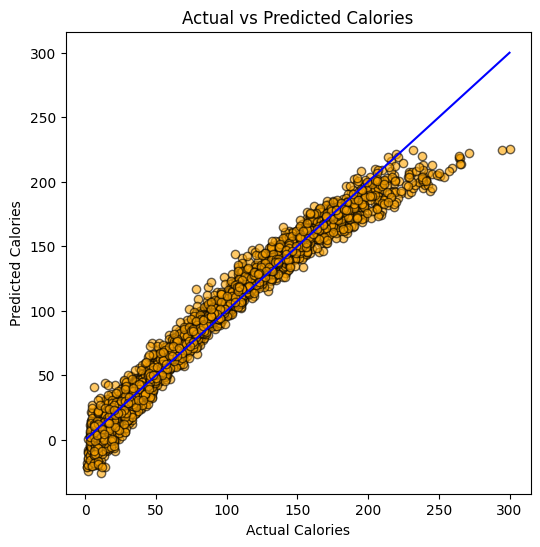

In [22]:
# =============================
# Q6: How to visualize predictions?
# =============================
y_pred = model.predict(X_val)

plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, color="orange", alpha=0.6, edgecolors="black")
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color="blue")
plt.show()


In [23]:
# =============================
# Q7: What is the role of normalization?
# =============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=22)
model_scaled = LinearRegression()
model_scaled.fit(X_train, y_train)

print("R² without normalization:", val_score)
print("R² with normalization:", model_scaled.score(X_val, y_val))


R² without normalization: 0.967058318318621
R² with normalization: 0.967058318318621


In [24]:
# =============================
# Q8: How to evaluate RMSE?
# =============================
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Root Mean Squared Error (RMSE):", rmse)


Root Mean Squared Error (RMSE): 11.252487201869044


In [25]:
# =============================
# Q9: Can we use polynomial regression?
# =============================
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])
poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_val)

poly_rmse = np.sqrt(mean_squared_error(y_val, poly_pred))
print("Polynomial Regression RMSE:", poly_rmse)


Polynomial Regression RMSE: 2.980118704609797


In [26]:
# =============================
# Q10: How to deploy the model? (Basic Export)
# =============================
import joblib
joblib.dump(model, "calories_model.pkl")
print("Model saved as calories_model.pkl (can be loaded for deployment)")


Model saved as calories_model.pkl (can be loaded for deployment)


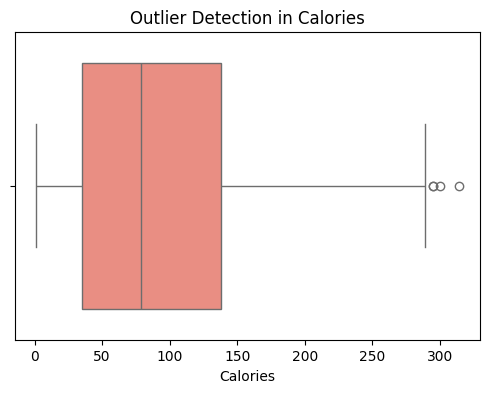

Shape before: (15000, 8)  | After removing outliers: (14996, 8)


In [27]:
# =============================
# Q11: How to detect and handle outliers?
# =============================
plt.figure(figsize=(6,4))
sb.boxplot(x=df['Calories'], color="salmon")
plt.title("Outlier Detection in Calories")
plt.show()

# Option: Remove extreme outliers
Q1, Q3 = df['Calories'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df_no_outliers = df[~((df['Calories'] < (Q1 - 1.5*IQR)) | (df['Calories'] > (Q3 + 1.5*IQR)))]
print("Shape before:", df.shape, " | After removing outliers:", df_no_outliers.shape)


In [28]:
# =============================
# Q12: How does feature scaling affect regression performance?
# =============================
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=22)

# Without scaling
model_raw = LinearRegression().fit(X_train, y_train)
raw_rmse = np.sqrt(mean_squared_error(y_val, model_raw.predict(X_val)))

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
model_scaled = LinearRegression().fit(X_train_scaled, y_train)
scaled_rmse = np.sqrt(mean_squared_error(y_val, model_scaled.predict(X_val_scaled)))

print("RMSE without scaling:", raw_rmse)
print("RMSE with scaling:", scaled_rmse)


RMSE without scaling: 11.252487201869044
RMSE with scaling: 11.252487201869043


In [29]:
# =============================
# Q13: What is the difference between training and validation error?
# =============================
train_pred = model.predict(X_train)
val_pred = model.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)


Training RMSE: 11.326199705983322
Validation RMSE: 11.252487201869044


In [30]:
# =============================
# Q14: How to avoid overfitting in linear regression?
# =============================
# Example with Ridge (regularization)
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

print("Ridge Train R²:", ridge_model.score(X_train, y_train))
print("Ridge Validation R²:", ridge_model.score(X_val, y_val))


Ridge Train R²: 0.9672254066263409
Ridge Validation R²: 0.9670581925782595


In [31]:
# =============================
# Q15: How does adding interaction terms improve predictions?
# =============================
poly_model_interactions = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=True)),
    ('linear', LinearRegression())
])
poly_model_interactions.fit(X_train, y_train)

interaction_pred = poly_model_interactions.predict(X_val)
interaction_rmse = np.sqrt(mean_squared_error(y_val, interaction_pred))

print("RMSE with interaction terms:", interaction_rmse)


RMSE with interaction terms: 2.978823896667389
